# Análise dos resultados do redutor — DE/rand/1/bin autoadaptativo

Este notebook analisa o problema de projeto do redutor de velocidades com Evolução Diferencial autoadaptativa. O problema possui sete variáveis, onze restrições de desigualdade e tratamento por penalização quadrática. A análise preserva as sementes e os orçamentos de avaliação armazenados nos arquivos CSV.

> **Escopo.** `best_objective` é o peso do projeto, enquanto `best_f` inclui a penalidade por violação. Esses valores só coincidem em soluções viáveis. O gráfico gerado por `plot_results.py` descreve a aptidão penalizada da população e não constitui, isoladamente, uma comparação estatística entre algoritmos.

## 1. Preparação e leitura dos dados

Os resultados finais são lidos de `results/`, enquanto as séries de convergência são lidas de `evolution_curves/`. Caminhos absolutos registrados nos CSVs não são necessários para a análise, o que facilita sua reprodução em outro ambiente.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

candidate = Path.cwd()
BASE_DIR = candidate if (candidate / 'plot_results.py').exists() else candidate / 'work_3' / 'gearbox'
if not (BASE_DIR / 'plot_results.py').exists():
    raise FileNotFoundError('Execute o notebook a partir de sua pasta ou da raiz do repositório.')

RESULTS_DIR = BASE_DIR / 'results'
CURVES_DIR = BASE_DIR / 'evolution_curves'
PLOTS_DIR = BASE_DIR / 'evolution_plots'

result_files = sorted(RESULTS_DIR.glob('*.csv'))
if not result_files:
    raise FileNotFoundError(f'Nenhum resultado CSV encontrado em {RESULTS_DIR}')

results = pd.concat((pd.read_csv(path) for path in result_files), ignore_index=True)
required_columns = {
    'best_f', 'best_objective', 'penalty',
    'max_constraint_violation', 'is_feasible',
}
missing_columns = required_columns.difference(results.columns)
if missing_columns:
    raise ValueError(f'Colunas ausentes nos resultados: {sorted(missing_columns)}')
results['is_feasible'] = (
    results['is_feasible'].astype(str).str.lower()
    .map({'true': True, 'false': False})
)
if results['is_feasible'].isna().any():
    raise ValueError('A coluna is_feasible contém valores inválidos.')
print(f'{len(results)} execuções carregadas de {len(result_files)} arquivo(s).')

21 execuções carregadas de 2 arquivo(s).


## 2. Síntese das execuções independentes

Para cada configuração, são reportadas estatísticas da aptidão penalizada e do objetivo original, além da quantidade de soluções viáveis e das violações. Como o problema é de minimização, valores menores são melhores, mas `best_objective` não deve ser comparado isoladamente quando a solução é inviável.

In [4]:
configuration_columns = [
    'algorithm', 'population_size', 'dimension',
    'max_fitness_evaluations', 'evaluation_step',
]
summary = (
    results.groupby(configuration_columns, dropna=False)
    .agg(
        execucoes=('best_f', 'count'),
        melhor_aptidao=('best_f', 'min'),
        mediana_aptidao=('best_f', 'median'),
        media_aptidao=('best_f', 'mean'),
        desvio_aptidao=('best_f', 'std'),
        melhor_objetivo=('best_objective', 'min'),
        mediana_objetivo=('best_objective', 'median'),
        viaveis=('is_feasible', 'sum'),
        mediana_violacao=('max_constraint_violation', 'median'),
        pior_violacao=('max_constraint_violation', 'max'),
    )
    .reset_index()
)
summary['taxa_viabilidade'] = summary['viaveis'] / summary['execucoes']
summary

,algorithm,population_size,dimension,max_fitness_evaluations,evaluation_step,execucoes,melhor_aptidao,mediana_aptidao,media_aptidao,desvio_aptidao,melhor_objetivo,mediana_objetivo,viaveis,mediana_violacao,pior_violacao,taxa_viabilidade
0,Self-adaptive DE/rand/1/bin with quadratic pen...,30,7,3030,30,19,2994.425365,2995.218855,2995.967248,2.181182,2994.250812,2995.069741,2,0.000095,0.000194,0.105263
1,Self-adaptive DE/rand/1/bin with quadratic pen...,30,7,36000,30,2,2994.387294,2994.387294,2994.387294,0.000000,2994.303532,2994.303532,0,0.000069,0.000069,0.000000


In [5]:
best_index = results.groupby(configuration_columns, dropna=False)['best_f'].idxmin()
best_runs = results.loc[best_index].sort_values(configuration_columns).reset_index(drop=True)
best_columns = configuration_columns + [
    'seed', 'best_f', 'best_objective', 'penalty',
    'max_constraint_violation', 'is_feasible',
    'best_x_0', 'best_x_1', 'best_x_2', 'best_x_3',
    'best_x_4', 'best_x_5', 'best_x_6',
    'mean_differential_weight', 'std_differential_weight',
    'mean_crossover_rate', 'std_crossover_rate',
]
best_runs[best_columns]

,algorithm,population_size,dimension,max_fitness_evaluations,evaluation_step,seed,best_f,best_objective,penalty,max_constraint_violation,...,best_x_1,best_x_2,best_x_3,best_x_4,best_x_5,best_x_6,mean_differential_weight,std_differential_weight,mean_crossover_rate,std_crossover_rate
0,Self-adaptive DE/rand/1/bin with quadratic pen...,30,7,3030,30,13,2994.425365,2994.322745,0.102620,0.000084,...,0.700002,17.000024,7.3,7.714949,3.350233,5.286506,0.378242,0.060981,0.900561,0.001212
1,Self-adaptive DE/rand/1/bin with quadratic pen...,30,7,36000,30,1,2994.387294,2994.303532,0.083762,0.000069,...,0.700000,17.000000,7.3,7.715141,3.350199,5.286552,0.829809,0.109575,0.909687,0.011151


## 3. Registro acadêmico breve

O relato abaixo é calculado diretamente dos CSVs. Ele distingue a melhor aptidão penalizada da melhor solução estritamente viável, adotando o mesmo limiar de viabilidade usado pelo algoritmo ($10^{-8}$). Essa distinção evita interpretar um objetivo baixo obtido mediante pequena violação como um projeto factível.

Também são apresentados a mediana entre sementes e os parâmetros autoadaptativos da população final. Eles descrevem o experimento realizado e não constituem comparação estatística com outro algoritmo.

In [6]:
for keys, group in results.groupby(configuration_columns, dropna=False):
    algorithm, population, dimension, budget, step = keys
    best = group.loc[group['best_f'].idxmin()]
    feasible = group[group['is_feasible']]
    feasible_count = len(feasible)
    best_feasible = None if feasible.empty else feasible.loc[feasible['best_objective'].idxmin()]
    design = ', '.join(f'{best[f"best_x_{index}"]:.6f}' for index in range(7))
    feasible_text = (
        'Nenhuma solução estritamente viável foi encontrada.'
        if best_feasible is None
        else f'A melhor solução viável teve objetivo {best_feasible["best_objective"]:.6f} '
             f'(seed {int(best_feasible["seed"])}).'
    )
    text = f'''
**{algorithm}.** Foram analisadas **{len(group)} execuções independentes**, com população {population}, dimensão {dimension}, orçamento de {budget} avaliações e registro a cada {step} avaliações. A menor aptidão penalizada foi **{best['best_f']:.6f}** (seed {int(best['seed'])}), com objetivo {best['best_objective']:.6f}, penalidade {best['penalty']:.3e} e violação máxima {best['max_constraint_violation']:.3e}. Seu vetor foi ({design}). A mediana da aptidão foi {group['best_f'].median():.6f}, com desvio-padrão amostral {group['best_f'].std():.6f}. **{feasible_count}/{len(group)}** execuções produziram solução estritamente viável. {feasible_text} Na população final da execução de menor aptidão, F = {best['mean_differential_weight']:.4f} ± {best['std_differential_weight']:.4f} e CR = {best['mean_crossover_rate']:.4f} ± {best['std_crossover_rate']:.4f}.
'''
    display(Markdown(text))


**Self-adaptive DE/rand/1/bin with quadratic penalty.** Foram analisadas **19 execuções independentes**, com população 30, dimensão 7, orçamento de 3030 avaliações e registro a cada 30 avaliações. A menor aptidão penalizada foi **2994.425365** (seed 13), com objetivo 2994.322745, penalidade 1.026e-01 e violação máxima 8.413e-05. Seu vetor foi (3.499837, 0.700002, 17.000024, 7.300000, 7.714949, 3.350233, 5.286506). A mediana da aptidão foi 2995.218855, com desvio-padrão amostral 2.181182. **2/19** execuções produziram solução estritamente viável. A melhor solução viável teve objetivo 2995.581025 (seed 12). Na população final da execução de menor aptidão, F = 0.3782 ± 0.0610 e CR = 0.9006 ± 0.0012.



**Self-adaptive DE/rand/1/bin with quadratic penalty.** Foram analisadas **2 execuções independentes**, com população 30, dimensão 7, orçamento de 36000 avaliações e registro a cada 30 avaliações. A menor aptidão penalizada foi **2994.387294** (seed 1), com objetivo 2994.303532, penalidade 8.376e-02 e violação máxima 6.873e-05. Seu vetor foi (3.499759, 0.700000, 17.000000, 7.300000, 7.715141, 3.350199, 5.286552). A mediana da aptidão foi 2994.387294, com desvio-padrão amostral 0.000000. **0/2** execuções produziram solução estritamente viável. Nenhuma solução estritamente viável foi encontrada. Na população final da execução de menor aptidão, F = 0.8298 ± 0.1096 e CR = 0.9097 ± 0.0112.


## 4. Curva da melhor execução

A rotina seleciona, em cada configuração, a seed com menor `best_f`. A linha representa a aptidão penalizada média da população e a faixa sombreada representa um desvio-padrão populacional. Como a penalidade faz parte dessa grandeza, a queda da curva pode resultar tanto da redução do peso quanto da redução das violações. A figura não mostra a incerteza entre execuções independentes.

Gráfico salvo em: /home/esterci/Repositorios/ppgmc/Evolutionary_Algorithms/work_3/gearbox/evolution_plots/melhor_execucao--pop-30--maxeval-3030--step-30.png
Gráfico salvo em: /home/esterci/Repositorios/ppgmc/Evolutionary_Algorithms/work_3/gearbox/evolution_plots/melhor_execucao--pop-30--maxeval-36000--step-30.png


**melhor_execucao--pop-30--maxeval-3030--step-30.png**

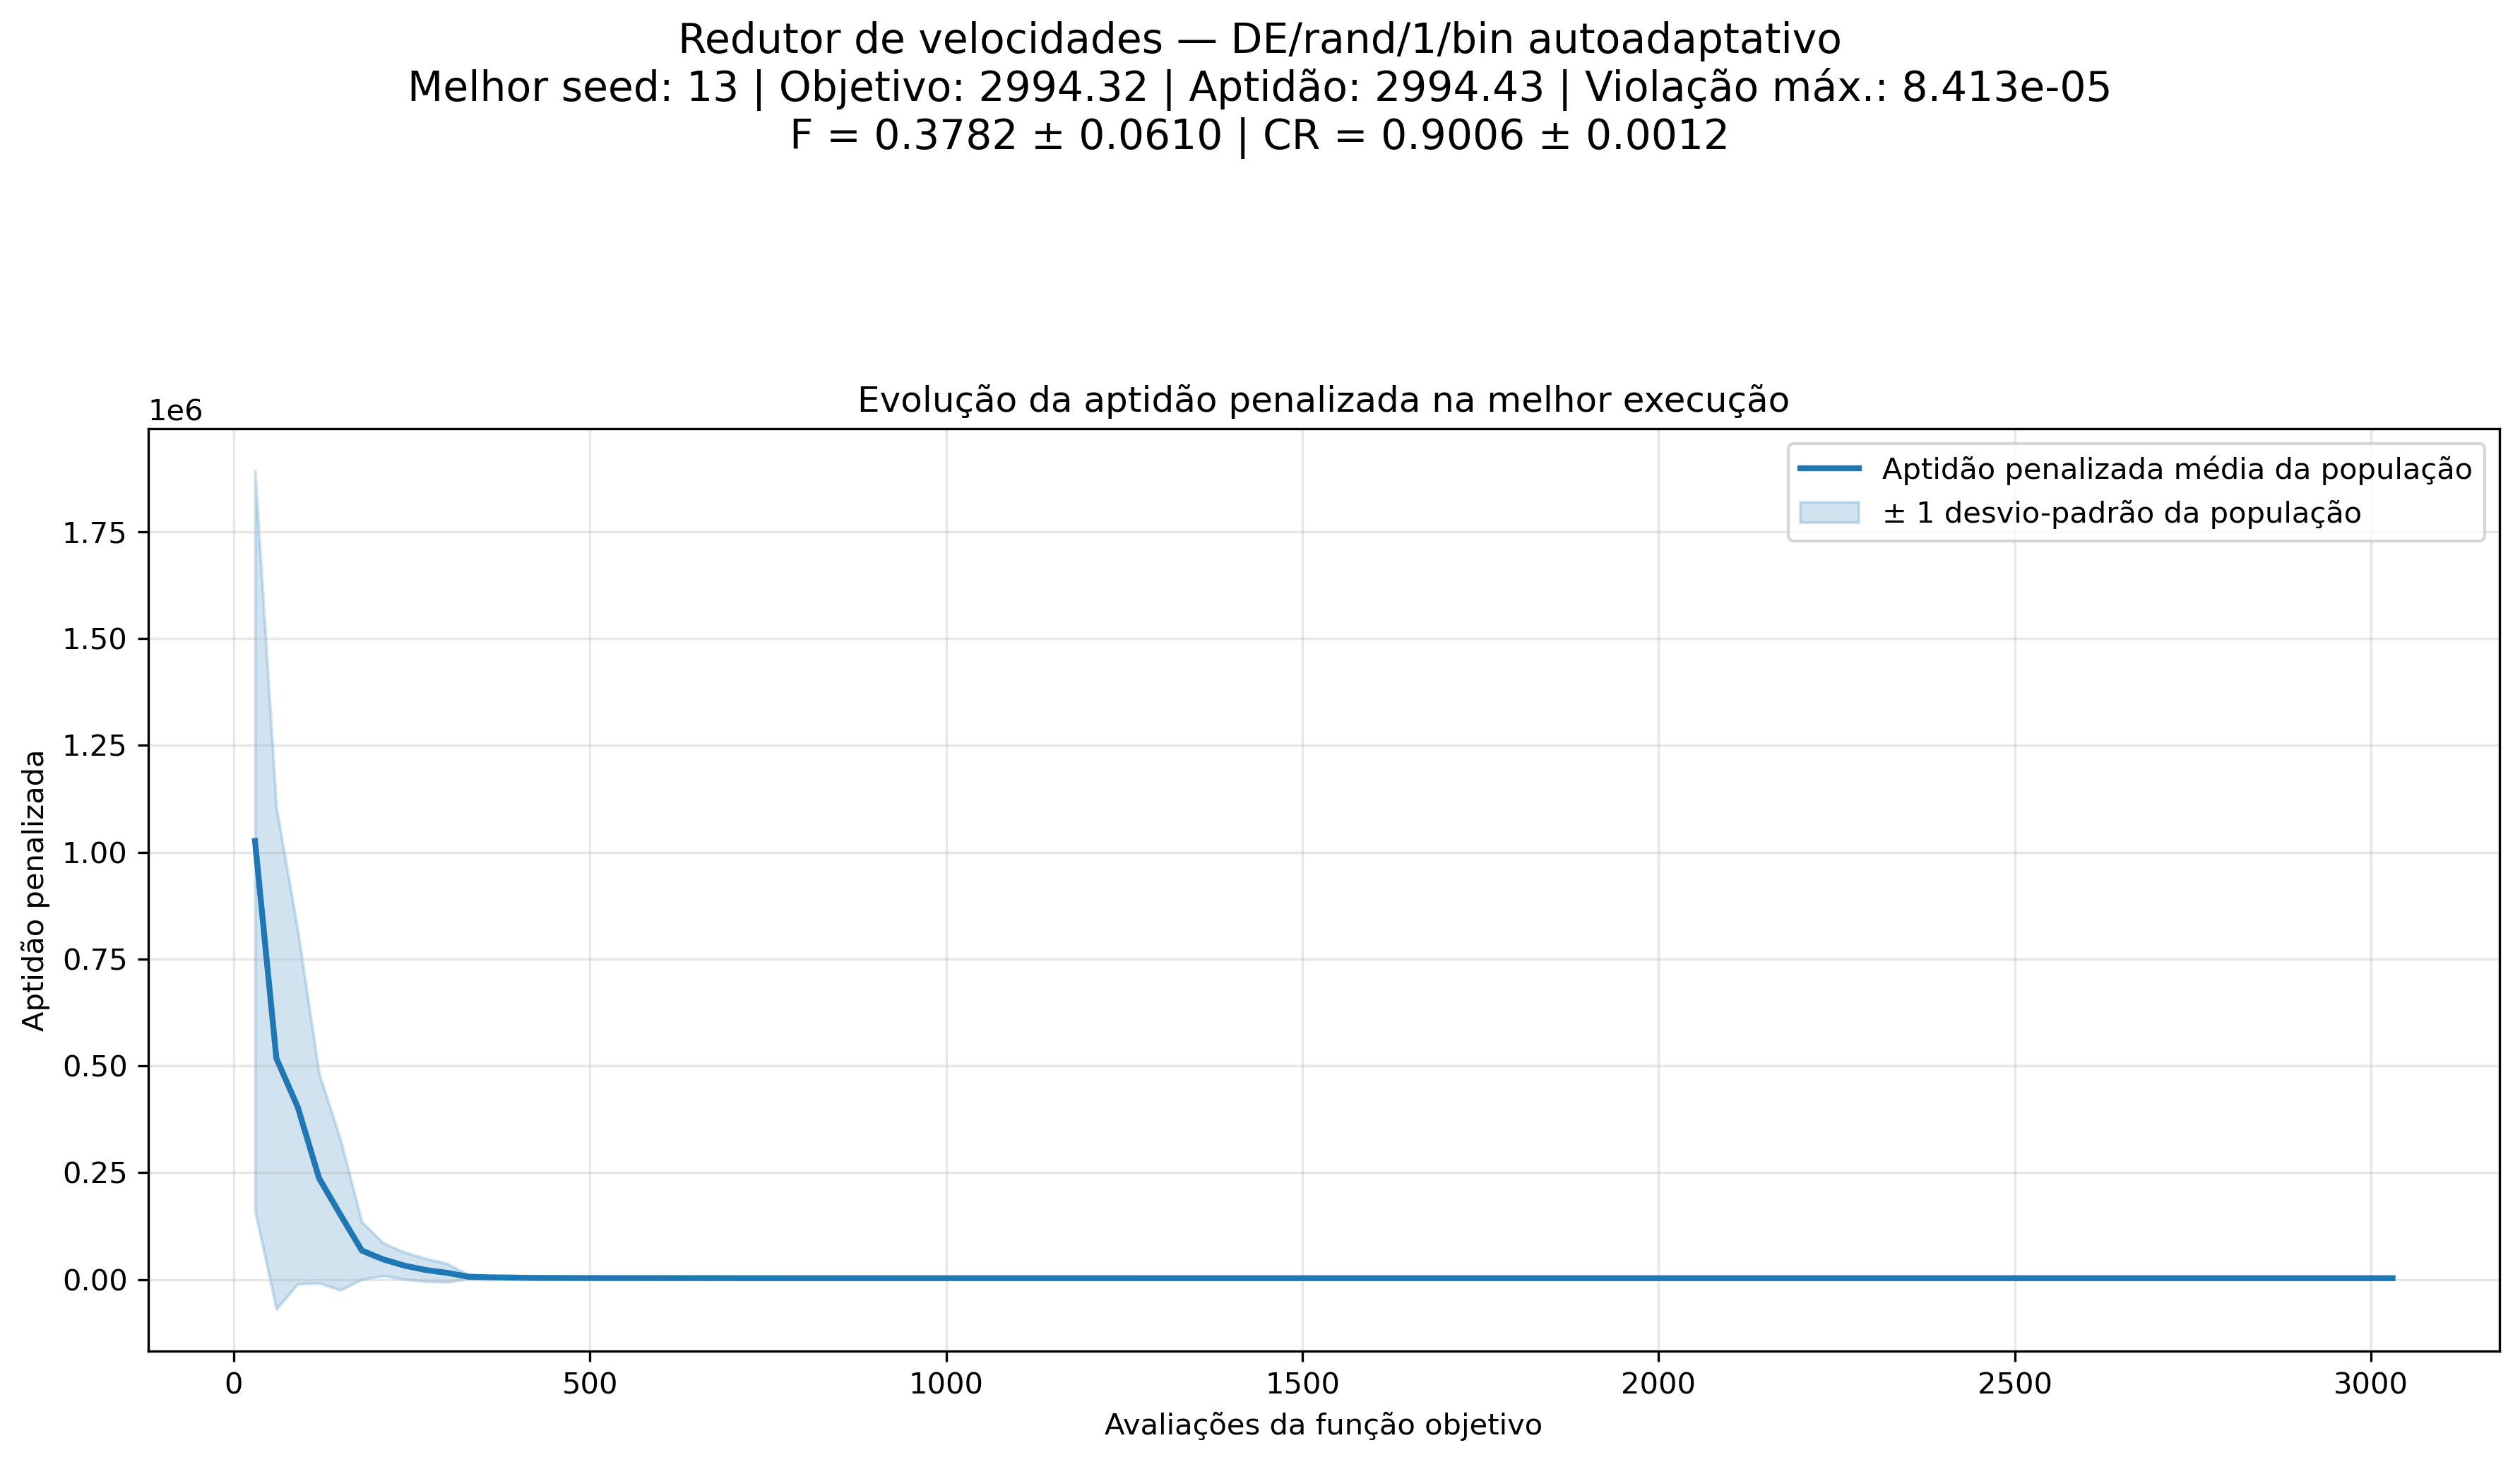

**melhor_execucao--pop-30--maxeval-36000--step-30.png**

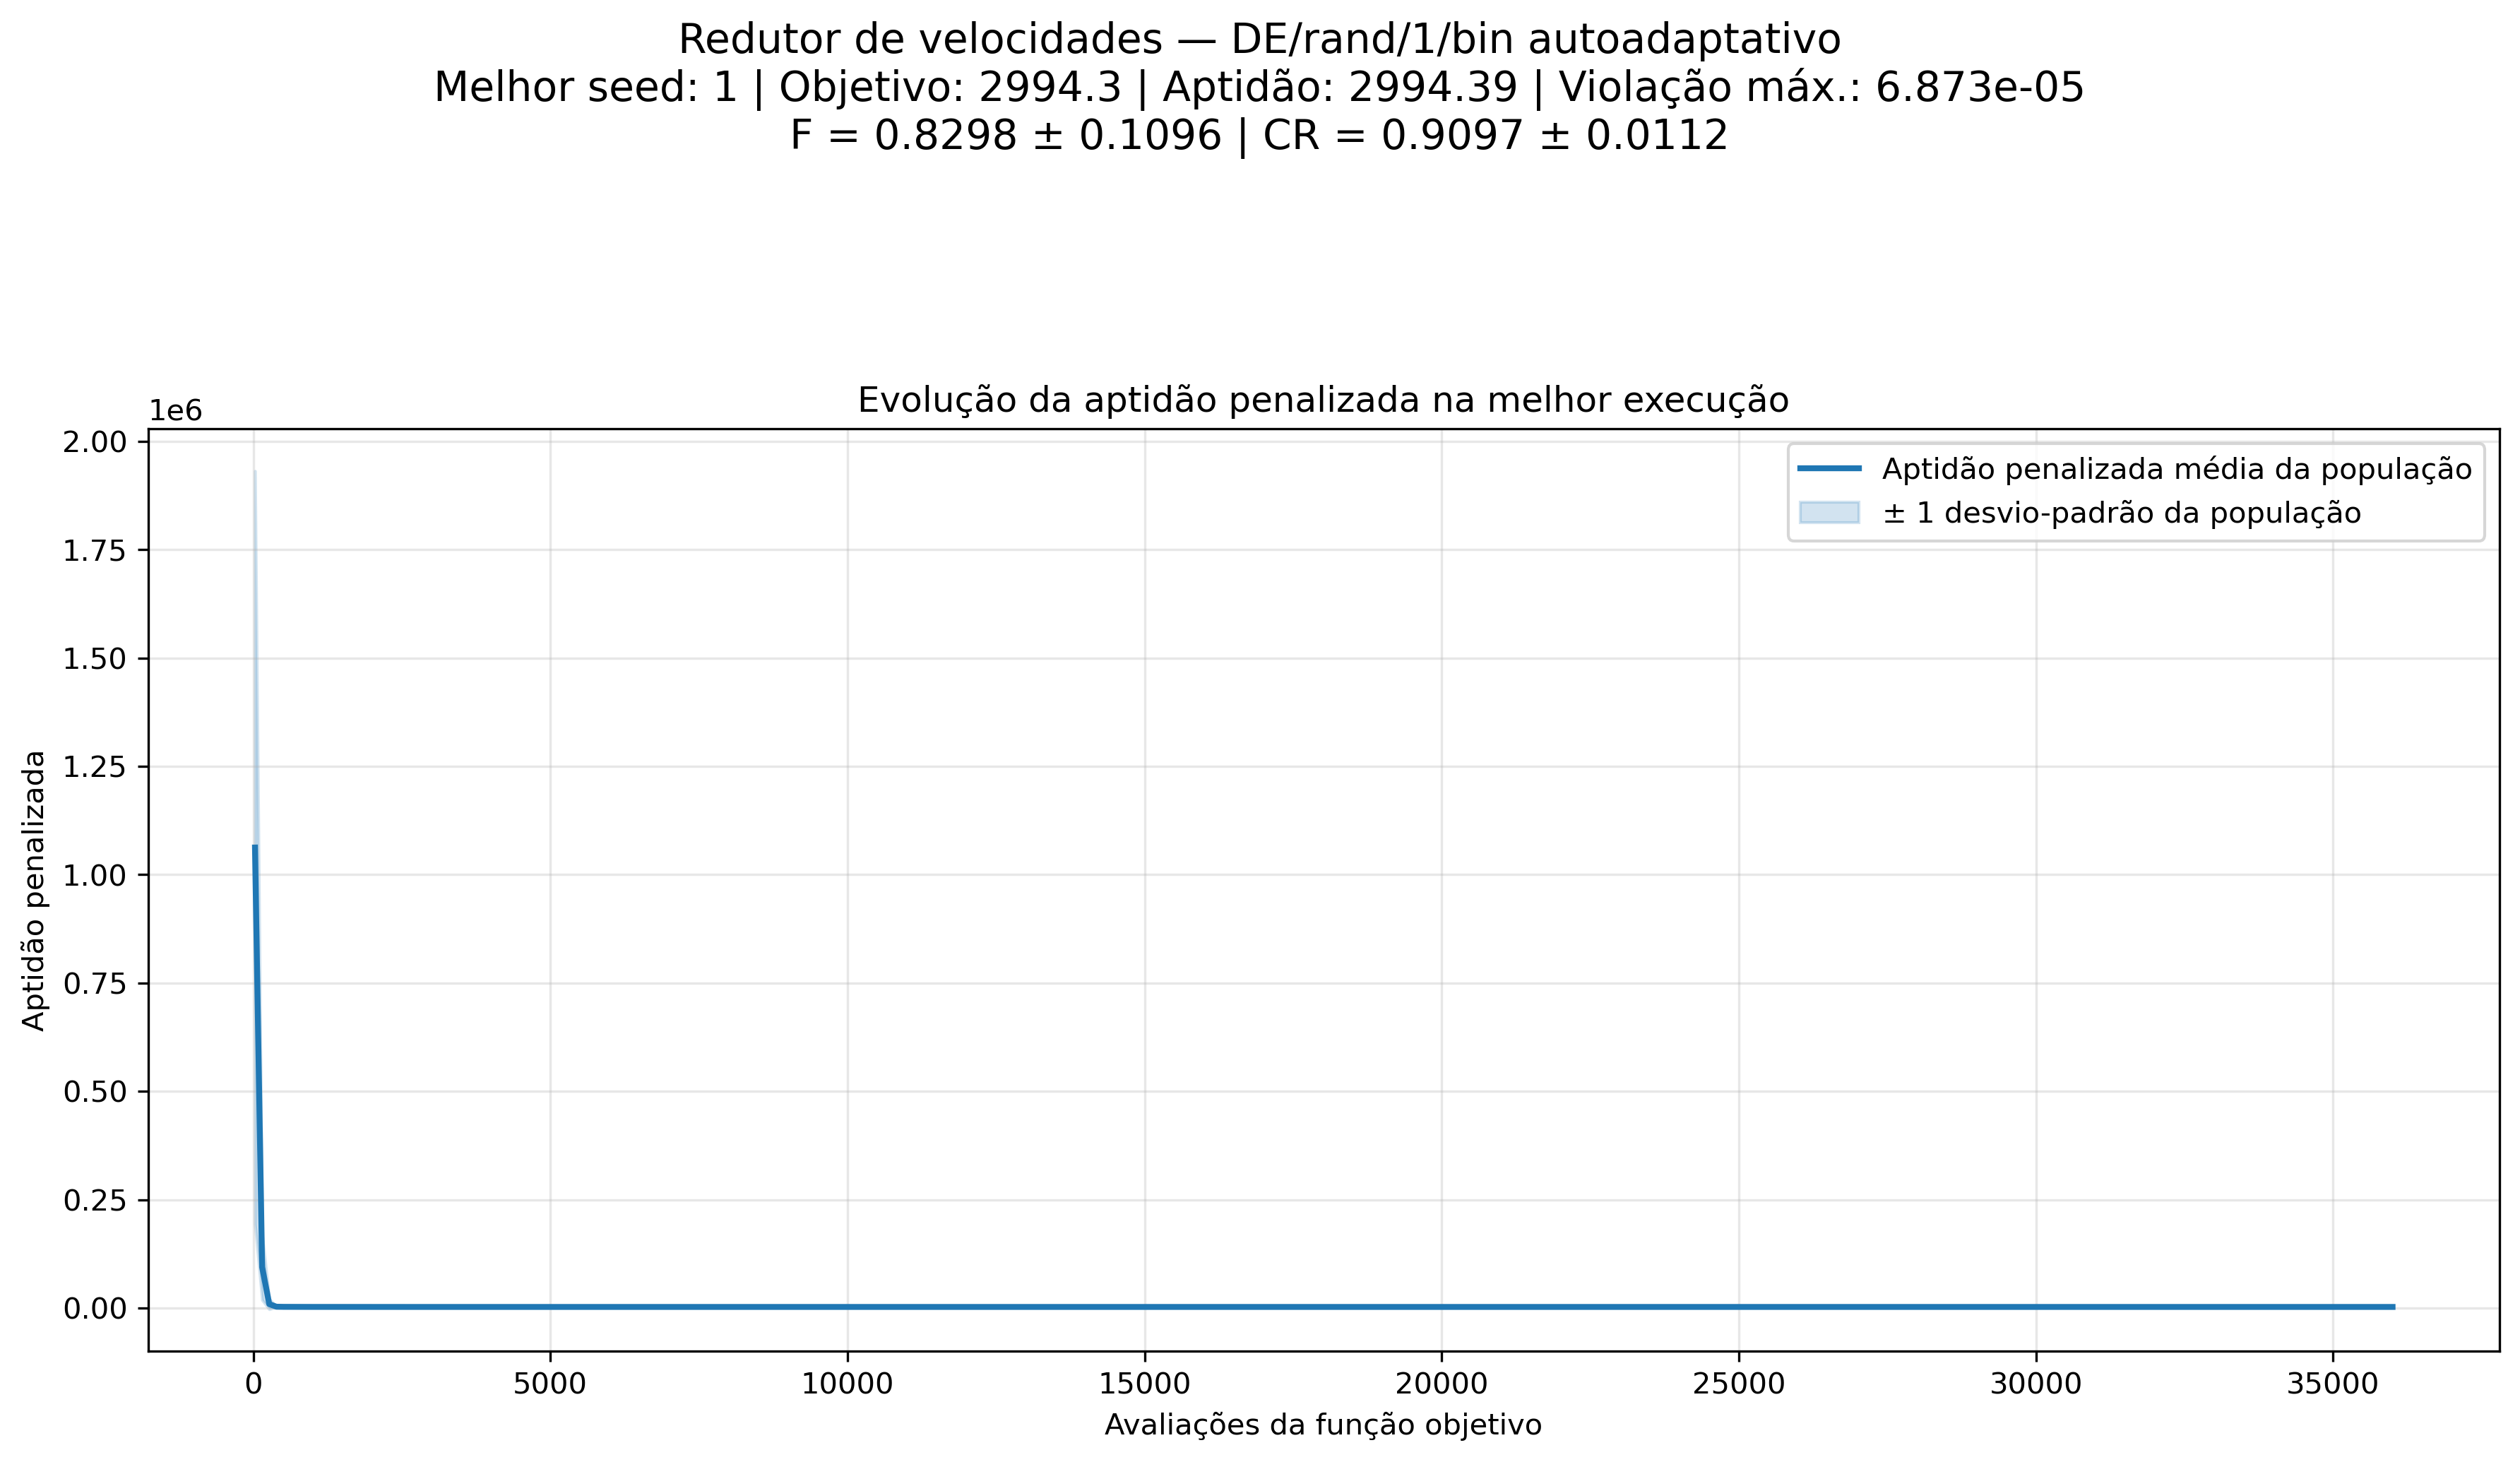

In [7]:
import importlib.util

module_spec = importlib.util.spec_from_file_location('plot_results', BASE_DIR / 'plot_results.py')
plot_results = importlib.util.module_from_spec(module_spec)
module_spec.loader.exec_module(plot_results)

plot_results.create_plots(CURVES_DIR, RESULTS_DIR, PLOTS_DIR)
for figure_path in sorted(PLOTS_DIR.glob('melhor_execucao--*.png')):
    display(Markdown(f'**{figure_path.name}**'))
    display(Image(filename=str(figure_path)))

## 5. Interpretação e limitações

A aproximação consistente de uma boa solução deve ser avaliada pelo conjunto das execuções, não apenas pela melhor curva. Nos resultados atuais, a baixa proporção de soluções estritamente viáveis mostra que aptidão penalizada e objetivo não devem ser usados como sinônimos. O fator de penalização é parte da configuração experimental e não deve ser alterado após observar os resultados apenas para melhorar números reportados. Comparações futuras devem manter orçamento, sementes, limites, fator de penalização e critério de viabilidade, além de reportar tendência central, dispersão e taxa de viabilidade.